## Module 9 Class activities
This notebook is a starting point for the exercises and activities that we'll do in class. We'll estimate topic models and do some sentiment analysis.

We'll continue with our example from last class: the [City of Palm Springs General Plan update](https://www.psgeneralplan.com).

Before you attempt any of these activities, make sure to watch the video lectures for this module.

### Reading and cleaning PDFs

Let's read in [this PDF of public comments](https://www.psgeneralplan.com/_files/ugd/89af76_0b8c3cd9a25140f4a9791570af8d6ba0.pdf). It's in the `data/` folder in your GitHub repository.

This is the code from last class. We read in the text of the PDF, and exclude the first 9 pages which are survey responses, not comments.

In [2]:
from pdfminer.high_level import extract_text

fn = '../classes/data/PS_VP_Survey_Results_FINAL.pdf'
txt = extract_text(fn)
txt = txt[txt.find("It doesn"):]

txt[:200] # see what it looks like

'It doesn’t speak about the people that are neither residents nor visitors. I work here with a lot of\npride. But I don’t consider myself a visitor.\n\n3/25/2020 3:22 PM\n\nHeight restrictions that are actu'

Before we clean up the text further, let's split this into a list of comments. Note that each comment seems to be separated by `AM\n\n` or `PM\n\n`. So if we split on `M\n\n`, we should get a list of comments.

Once you have a list, now we can clean it up using regex. Here's my suggestion:
* write a function that takes a string, and returns a clean string (remove excess whitespace and characters that are not letters or a space)
* create a new list by applying this function to each element of your list of comments

The latter can be done with something like:

`newlist = [clean_string(comment) for comment in oldlist]`.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a list of cleaned comments.
</div>

In [3]:
import re
def clean_string(comment):
    # your code here
    return cleaned_comment

# create a list of comments
comments = 999 # # your code here 

# then a list of cleaned comments


def clean_string(comment):
    comment = re.sub(r"\s+", " ", comment)  # remove excess whitespace
    comment = re.sub(r"[^A-z\s]", "", comment)  # remove characters that are not letters\
    comment = re.sub(r"\s+", " ", comment)      # repeat step 1 to remove any new whitespace created in the previous step
    return comment

comments = txt.split('M\n\n')
comments = [clean_string(comment) for comment in comments]
comments[:10] # take a look

['It doesnt speak about the people that are neither residents nor visitors I work here with a lot of pride But I dont consider myself a visitor P',
 'Height restrictions that are actually adhered to Completion Bonds on all projects in Palm Springs P',
 ' James O Jessen Community Center updated Traffic lights crosswalk Pickleball courts Community Gardens and Art Park P',
 'Expand economic opportunities to include Green energy workforce training Workforce development to become a diversified economy Create more affordable Housing for single family residential P',
 'Many areas in the City are blighted and lack funding to advance the lower income areas of the Northern communities P',
 'Also needs to focus on health and wellbeing issues Revisit Economic Growth Incorporate Sustainability for local just visitors While we are a resort town residents seem to be forced out due to increase in sustaining visitorship Not sure at this point a reference to environmental issues is needed Change the phr

One final cleaning step: you probably notice that all your comments end in `P` or `A`. 

Remove these terminal letters from each comment (or just delete the last two characters of each comment). And remove comments that are just ` P` or ` A` (perhaps you can ignore all comments that are less than, say, 5 characters long).

*Hint*: Try another list comprehension (or two).

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Clean up your comments further and drop the short ones.
</div>

In [4]:
# your code here

comments = [comment[:-2] for comment in comments] # remove last two characters
comments = [comment for comment in comments if len(comment)>=5] # drop short comments
comments[:10] # take a look

['It doesnt speak about the people that are neither residents nor visitors I work here with a lot of pride But I dont consider myself a visitor',
 'Height restrictions that are actually adhered to Completion Bonds on all projects in Palm Springs',
 ' James O Jessen Community Center updated Traffic lights crosswalk Pickleball courts Community Gardens and Art Park',
 'Expand economic opportunities to include Green energy workforce training Workforce development to become a diversified economy Create more affordable Housing for single family residential',
 'Many areas in the City are blighted and lack funding to advance the lower income areas of the Northern communities',
 'Also needs to focus on health and wellbeing issues Revisit Economic Growth Incorporate Sustainability for local just visitors While we are a resort town residents seem to be forced out due to increase in sustaining visitorship Not sure at this point a reference to environmental issues is needed Change the phrasing word

### Sentiment analysis
Now we have our cleaned up list of comments. Let's do some sentiment analysis. If we create a dataframe with our comments (as one column) and the polarity score (as a second column), the analysis later on becomes easier.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a list of polarity scores, one for each comment. Then create a dataframe, with one column for the comment and one for the polarity score.</div>

In [5]:
from textblob import TextBlob
import pandas as pd

# your code here
sentiment = [TextBlob(comment).sentiment.polarity for comment in comments]
df = pd.DataFrame([comments, sentiment]).T
df.columns= ['comment', 'polarity']

Take a look at the comments with some of the highest and lowest polarity scores. Do the scores make sense? What words is it picking up on?

Note that a simple sentiment analyzer like TextBlob won't capture nuances, but in aggregate the results can be useful.

In [6]:
# your code here

print('Lowest scores:')
print(df[df.polarity<-0.2].comment.values)
print('Highest scores:')
print(df[df.polarity>0.5].comment.values)

Lowest scores:
['Does not mention activitiesattractionsadventure but rather a leisure experience Hard to say what years will look like'
 'link sustainable economic growth with a diversified employment base beyond lower wage service jobs'
 'Building heights would have to be raised for efficient use of land and that would destroy the small town ambience Waste of water is obscene'
 'Why reduce the need for vehicle use when the sidewalks and crossing streets are so difficult and unsafe'
 'This is a joke The improvement Indian Canyon running two ways has made traffic worse than it ever was'
 'This is vague also its redundant you already mention the reduced dependence on motor vehicles maybe roll this message into the previous one'
 'Im not sure this manifests itself in the city Weve already lost the oneway streets which I think']
Highest scores:
['We need to prioritize good environmental stewardship innovation and diversityinclusion in a more intentional way'
 'Should also state accepts div

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Do some plots of the sentiment and other analyses that try and capture sentiment on particular issues.</div>

For example, after you plot the overall sentiment scores (a histogram?), you might want to plot the scores where people mention specific issues. For example, you could add a column that is `True` if the comment mentions housing, and then plot the scores only for those rows. Experiment!

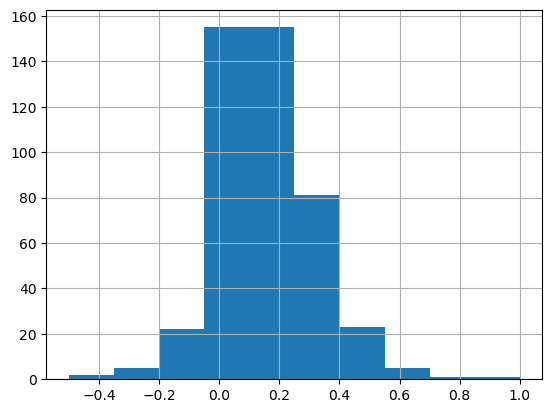

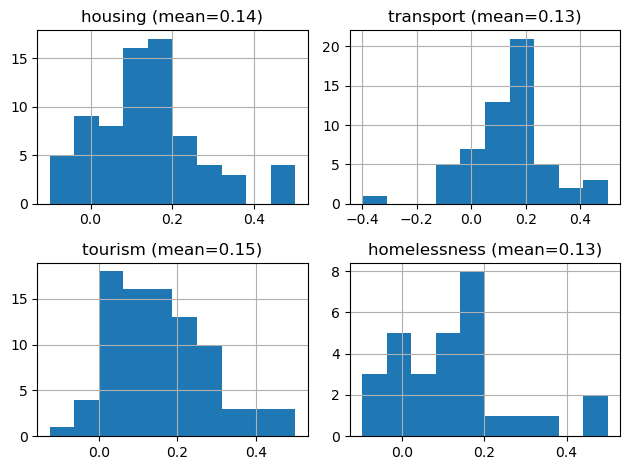

In [7]:
# your code here
df.polarity.hist()

# what about by issue
# str.contains()とapply(lambda ...)の違い
# str.contains()は、単純な文字列チェックや部分一致に有効（速い）
# apply(lambda ...)は、複数語チェックや複雑な条件付きの処理に有効

# df.commentで、dfの中のcomment列を取り出す
# str.lower()でコメントをすべてを小文字に変換
# .apply(lambda ...)で各コメント（1行ずつ）に対して処理を実行
# 'transport' in x or 'traffic' in x、は小文字化されたコメントxにtransportまたはtrafficが含まれていないかチェック
# df['transport'] = でその判定結果（True/False）を格納
df['housing'] = df.comment.str.lower().str.contains('hous')
df['transport'] = df.comment.str.lower().apply(lambda x: 'transport' in x or 'traffic' in x)
df['tourism'] = df.comment.str.lower().apply(lambda x: 'touris' in x or 'resort' in x)
df['homelessness'] = df.comment.str.lower().str.contains('homeless')


# plot them
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,2)
issues = ['housing', 'transport', 'tourism', 'homelessness']
for ii, ax in enumerate(axes.ravel()):
    issue = issues[ii]
    df[df[issue]].polarity.hist(ax=ax)
    mean_score = df[df[issue]].polarity.mean()
    ax.set_title(issue+' (mean={:.2f})'.format(mean_score))
fig.tight_layout()

## Topic modeling
Now let's see if we can identify different topics in the list of comments.

First, we'll need to do a bit more cleanup. For each comment, turn it into a list of words, and exclude stopwords. (After you see the results of your topic modeling, you might want to add more stopwords.) You should end up with a list of lists.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Turn your list of comments into a list of lists of words, excluding stopwords.</div>

In [8]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# your code here
swords = stopwords.words('english')
# these are extra stopwords I added after looking at the results
swords += ['city', 'palm', 'springs', 'ps', 'need', 'needs', 'priority', 'general', 'plan']
wordlists = [[word for word in word_tokenize(comment.lower()) 
                 if word not in swords] 
                 for comment in comments]
wordlists[:2] # take a look

[['doesnt',
  'speak',
  'people',
  'neither',
  'residents',
  'visitors',
  'work',
  'lot',
  'pride',
  'dont',
  'consider',
  'visitor'],
 ['height',
  'restrictions',
  'actually',
  'adhered',
  'completion',
  'bonds',
  'projects']]

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Estimate and visualize a topic model from your wordlists. Experiment with the number of topics and the other hyperparameters.</div>

Remember: 
* `alpha` controls the expected distribution of topics across documents. A higher value of `alpha` means that each document is expected to contain more of a mix of topics, rather than focusing on a few topics.
* `eta` (sometimes called beta) controls the expected distribution of words across topics. A higher value of `eta` means that topics are more similar in terms of their mixture of words.

In [9]:
import gensim
import pyLDAvis
import pyLDAvis.gensim_models 

# your code here

dictionary = gensim.corpora.Dictionary(wordlists)
corpus = [dictionary.doc2bow(wl) for wl in wordlists]
model = gensim.models.LdaMulticore(corpus, id2word=dictionary, num_topics=5, alpha=0.2, eta=0.5)
pyLDAvis.enable_notebook()
pyLDAvis.gensim_models.prepare(model, corpus, dictionary)

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=45272) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=45272) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=45272) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=45272) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/lo

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.016675  0.011908       1        1  24.543310
0      0.005943 -0.011830       2        1  23.666605
4     -0.035399  0.004382       3        1  19.862870
1      0.005023 -0.022462       4        1  16.661744
2      0.007758  0.018002       5        1  15.265471, topic_info=              Term       Freq      Total Category  logprob  loglift
43         housing  86.000000  86.000000  Default  30.0000  30.0000
1263       smoking   7.000000   7.000000  Default  29.0000  29.0000
1261  preparedness   7.000000   7.000000  Default  28.0000  28.0000
1256     alternate   7.000000   7.000000  Default  27.0000  27.0000
780         living  19.000000  19.000000  Default  26.0000  26.0000
...            ...        ...        ...      ...      ...      ...
331       business   5.528404  34.147801   Topic5  -5.8834   0.0588
250     priorities   5.545378  39.029163   Topic5  -5.8803  -0.0718
35     development   5.519905  39.867228   Topic5  -5.8849  -0.0976
21       community   5.746987  46.048499   Topic5  -5.8446  -0.2014
30         traffic   4.838267  34.720792   Topic5  -6.0167  -0.0912

[366 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
148       1  0.433531       add
148       2  0.192680       add
148       3  0.144510       add
148       4  0.144510       add
148       5  0.096340       add
...     ...       ...       ...
1254      5  0.085437       yes
1560      1  0.559887  yielding
1560      2  0.279944  yielding
894       1  0.374258   younger
894       5  0.374258   younger

[884 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 5, 2, 3])

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Explain your topic model - write a sentence or two, and explain to your neighbor. What does each topic signify, and how did you choose alpha and eta?</div>

Your comments here.

## Extensions to topic modeling and sentiment analysis
One potential use of these models is to look at differences across space or across time. 

Or we could look at how word frequency changes across space or cities.

You could also feed the text to a generative AI API (e.g. the Google Gemini API which we experimented with in Week 2).

If you have time, try this with the San Francisco Board of Supervisors meetings. [This webpage](http://sanfrancisco.granicus.com/ViewPublisher.php?view_id=10) gives the archived transcripts ("caption notes").

You could scrape all of the URLs (that's a good exercise!), but for now, just manually create a list with a 10-20 or so of the caption notes.

Write a function that for a given URL:
* Gets the text (use `requests`)
* Cleans the text
* Tokenizes (splits into words)

Then, think about how you might estimate a topic model.

Would sentiment analysis be useful here?

This is an open-ended prompt, so spend some time thinking through the steps conceptually, even if you don't get far in implementing it. For example, how will you organize the text of each documents and the counts? In a list? A dataframe? Will you loop through each URL?

In [10]:
# create a new kernel using the genai environment (conda activate genai)
# you'll need an API key, but some Gemini LLMs are free (for now)
from google import genai  # if this doesn't load, you probably have the wrong environment
gemini_api_key = 'XXXX' #'XXXXX' # fill in your key here

# the free version of Gemini can't get URLs, so we have to do it ourself
from pdfminer.high_level import extract_text
fn = '../classes/data/PS_VP_Survey_Results_FINAL.pdf'
txt = extract_text(fn)
                  
c = genai.Client(api_key=gemini_api_key)
chat = c.chats.create(model='gemini-2.0-flash-001')
response = chat.send_message('What are the topics in this document?: '+txt)
print(response.text)


ModuleNotFoundError: No module named 'google'

In [ ]:
# maybe we should be more specific
response = chat.send_message('I mean: in the public comments, please classify the comments into 5 topics.')
print(response.text)

In [ ]:
# seems better, but we should verifiy
response = chat.send_message('Please give 2 examples of the comments that reflect each topic.')
print(response.text)

In [ ]:
response = chat.send_message('What percentage of the comments fall into each topic?')
print(response.text)

In [ ]:
# let's look at sentiment
# how does this compare to our results above?

response = chat.send_message('What is the average sentiment of comments that address (i) housing, (ii) transportation, (iii) tourism, and (iv) homelessness. Please give a score for each on a scale from -1 to +1.')
print(response.text)

In [ ]:
response = chat.send_message('''Please provide the numerical scores in a python dict format {}.
    The keys should be housing, transportation, tourism, and homelessness''')
print(response.text)

##### LLMを使ってpython dictのformatで結果を吐き出させることは可能。つまり、分析ステップの一部をLLMにお願いして、それをpythonのフォーマットで返させれば、その後のプロセスをpythonで続ける事が可能。

In [ ]:
# we can use the Python eval command to evaluate this string
# we strip out the python at the start of the string, 
# and also the quotes that are the 1st 3 and last 3 characters
d = eval(response.text.replace('python','')[3:-3])
print(d)

# for a more advanced way to do this,
# the docs have some examples: https://ai.google.dev/gemini-api/docs/structured-output


<div class="alert alert-block alert-info">
<h3>You should now be able to:</h3>
<ul>
  <li>Do further cleaning of text documents</li>
  <li>Estimate and interpret sentiments of texts</li>
  <li>Estimate and interpret topic models</li>
</ul>
</div>